In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import yaml
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_loader, load_data
from encoder import Encoder
from dann import DANNModel
from utils import deterministic
from dann_utils import train_baseline, train_dann, evaluate

In [3]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Baseline

In [4]:

experiment_parameters = config["dann_baseline"]

epochs = experiment_parameters["epochs"]
batch_size = experiment_parameters["batch_size"]
workers = experiment_parameters["num_workers"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

lr = experiment_parameters["lr"]

data = "Mnist"
train_source_loader = load_loader("train", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)
val_source_loader = load_loader("val", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

data = "Mnist_M"
val_target_loader = load_loader("val", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
baseline_model = DANNModel(encoder)
baseline_model.to(device)

optimizer = torch.optim.Adam(baseline_model.parameters(), lr=lr)

In [5]:
deterministic(config["xtra"]["seed"])
baseline_history = train_baseline(baseline_model, train_source_loader, val_source_loader, val_target_loader,
            optimizer, epochs=epochs, device=device)

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

Hacer Early stopping!!

In [6]:
path = "../results/dann_baseline_history.yaml"
with open(path, "w") as f:
    yaml.dump(baseline_history, f)

In [7]:
path = "../models/weights/dann_baseline.pth"
baseline_model.save(path)

### Baseline Finetunning Mnist-M

In [8]:

experiment_parameters = config["dann_baseline"]

epochs = experiment_parameters["epochs"]
batch_size = experiment_parameters["batch_size"]
workers = experiment_parameters["num_workers"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

lr = experiment_parameters["lr"]

data = "Mnist_M"
train_source_loader = load_loader("train", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)
val_source_loader = load_loader("val", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

data = "Mnist"
val_target_loader = load_loader("val", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
baseline_ft_model = DANNModel(encoder)
baseline_ft_model.load("../models/weights/dann_baseline.pth", device)

optimizer = torch.optim.Adam(baseline_ft_model.parameters(), lr=lr)

In [9]:
deterministic(config["xtra"]["seed"])
baseline_ft_history = train_baseline(baseline_ft_model, train_source_loader, val_source_loader, val_target_loader,
            optimizer, epochs=epochs, device=device)

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

In [10]:
path = "../results/baseline_ft_history.yaml"
with open(path, "w") as f:
    yaml.dump(baseline_ft_history, f)

In [11]:
path = "../models/weights/dann_baseline_ft.pth"
baseline_ft_model.save(path)

### DANN

In [12]:
experiment_parameters = config["dann"]

epochs = experiment_parameters["epochs"]
batch_size = experiment_parameters["batch_size"]
workers = experiment_parameters["num_workers"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

lr = experiment_parameters["lr"]

data = "Mnist"
train_source_loader = load_loader("train", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)
val_source_loader = load_loader("val", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

data = "Mnist_M"
train_target_loader = load_loader("train", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)
val_target_loader = load_loader("val", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
dann_model = DANNModel(encoder)
dann_model.to(device)

optimizer = torch.optim.Adam(dann_model.parameters(), lr=lr)

In [13]:
deterministic(config["xtra"]["seed"])
dann_history = train_dann(dann_model, train_source_loader, val_source_loader, train_target_loader, val_target_loader,
            optimizer, epochs=epochs, device=device)

Epochs:   0%|          | 0/600 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Early stopping!

In [14]:
path = "../results/dann_history.yaml"
with open(path, "w") as f:
    yaml.dump(dann_history, f)

In [15]:
path = "../models/weights/dann.pth"
dann_model.save(path)

### Comparación

In [16]:
path = "../results/dann_baseline_history.yaml"
with open(path, "r") as f:
    baseline_history = yaml.safe_load(f)

path = "../results/baseline_ft_history.yaml"
with open(path, "r") as f:
    baseline_ft_history = yaml.safe_load(f)

path = "../results/dann_history.yaml"
with open(path, "r") as f:
    dann_history = yaml.safe_load(f)

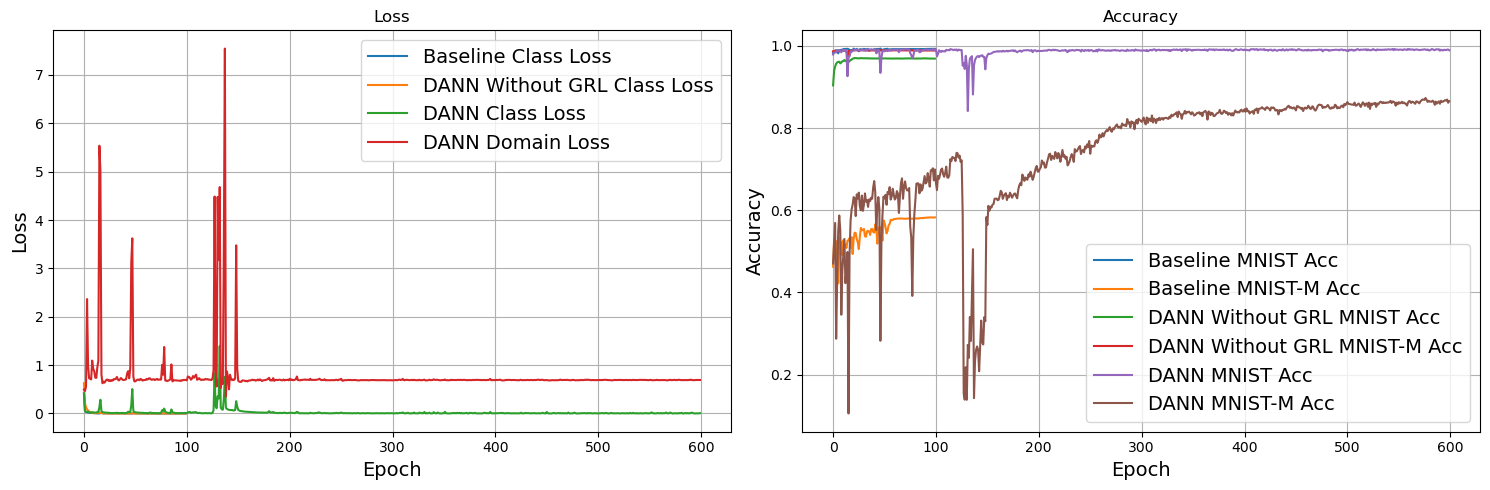

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
fontsize = 14
ax[0].plot(baseline_history["train_class_loss"], label="Baseline Class Loss")


ax[0].plot(baseline_ft_history["train_class_loss"], label="DANN Without GRL Class Loss")

ax[0].plot(dann_history["train_class_loss"], label="DANN Class Loss")
ax[0].plot(dann_history["train_domain_loss"], label="DANN Domain Loss")

ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch", fontsize=fontsize)
ax[0].set_ylabel("Loss", fontsize=fontsize)
ax[0].grid()
ax[0].legend(fontsize=fontsize)


ax[1].plot(baseline_history["val_source_acc"], label="Baseline MNIST Acc")
ax[1].plot(baseline_history["val_target_acc"], label="Baseline MNIST-M Acc")

ax[1].plot(baseline_ft_history["val_source_acc"], label="DANN Without GRL MNIST Acc")
ax[1].plot(baseline_ft_history["val_target_acc"], label="DANN Without GRL MNIST-M Acc")

ax[1].plot(dann_history["val_source_acc"], label="DANN MNIST Acc")
ax[1].plot(dann_history["val_target_acc"], label="DANN MNIST-M Acc")

ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch", fontsize=fontsize)
ax[1].set_ylabel("Accuracy", fontsize=fontsize)
ax[1].legend(fontsize=fontsize)
ax[1].grid()

plt.tight_layout()
plt.show()


In [37]:
batch_size = 32
workers = 0

data = "Mnist"
test_source_loader = load_loader("test", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

data = "Mnist_M"
test_target_loader = load_loader("test", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

data = "Svhn"
test_svhn_loader = load_loader("test", config[data]["dataset_output_dir"], batch_size=batch_size, num_workers=workers)

test_data = {"Mnist": test_source_loader,
             "Mnist-M": test_target_loader}

In [38]:
experiment_parameters = config["dann_baseline"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
dann_baseline_model = DANNModel(encoder)
dann_baseline_model.load("../models/weights/dann_baseline.pth", device)

In [39]:
baseline_s_acc = evaluate(dann_baseline_model, test_source_loader, device)
baseline_t_acc = evaluate(dann_baseline_model, test_target_loader, device)
baseline_svhn_acc = evaluate(dann_baseline_model, test_svhn_loader, device)

In [40]:
experiment_parameters = config["dann_without_grl"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
dann_baseline_ft_model = DANNModel(encoder)
dann_baseline_ft_model.load("../models/weights/dann_baseline_ft.pth", device)

In [41]:
dann_baseline_ft_s_acc = evaluate(dann_baseline_ft_model, test_source_loader, device)
dann_baseline_ft_t_acc = evaluate(dann_baseline_ft_model, test_target_loader, device)
dann_baseline_ft_svhn_acc = evaluate(dann_baseline_ft_model, test_svhn_loader, device)

In [42]:
experiment_parameters = config["dann"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
dann_model = DANNModel(encoder)
dann_model.load("../models/weights/dann.pth", device)

In [43]:
dann_s_acc = evaluate(dann_model, test_source_loader, device)
dann_t_acc = evaluate(dann_model, test_target_loader, device)
dann_svhn_acc = evaluate(dann_model, test_svhn_loader, device)

In [44]:
results_df = pd.DataFrame({
    "Model": ["Baseline", "Baseline ft","DANN"],
    "Accuracy Mnist": [round(baseline_s_acc, 4), round(dann_baseline_ft_s_acc, 4) ,round(dann_s_acc, 4)],
    "Accuracy Mnist_M": [round(baseline_t_acc, 4), round(dann_baseline_ft_t_acc, 4), round(dann_t_acc, 4)],
    "Accuracy Svhn": [round(baseline_svhn_acc, 4), round(dann_baseline_ft_svhn_acc, 4), round(dann_svhn_acc, 4)]
})
print(results_df)

         Model  Accuracy Mnist  Accuracy Mnist_M  Accuracy Svhn
0     Baseline          0.9952            0.5719         0.3234
1  Baseline ft          0.9884            0.9706         0.3538
2         DANN          0.9923            0.8635         0.3036


In [45]:
data = "Mnist"
test_mnist_images, test_mnist_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Mnist_M"
test_mnist_m_images, test_mnist_m_labels = load_data("test", config[data]["dataset_output_dir"])

test_data = {"Mnist": (test_mnist_images, test_mnist_labels),
             "Mnist-M": (test_mnist_m_images, test_mnist_m_labels)}

In [46]:
from utils import select_fixed_subset
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def get_embeddings_labels(models, models_name, fixed_images_labels, device):

    all_embeddings = []
    all_labels = []
    all_domains = []
    all_models = []

    for model, model_name in zip(models, models_name):
        model.eval()
        embeddings_labels = {}

        with torch.no_grad():
            for domain in fixed_images_labels:
                images, labels = fixed_images_labels[domain]
                images = images.to(device)
                embeddings = model.encoder(images).cpu().numpy()
                labels = labels.cpu().numpy()
                embeddings_labels[domain] = (embeddings, labels)

        all_embeddings_model = []
        all_labels_model = []
        all_domains_model = []
        all_models_model = []

        for domain in embeddings_labels:
            embeddings, labels = embeddings_labels[domain]
            all_embeddings_model.append(embeddings)
            all_labels_model.append(labels)
            all_domains_model.extend([domain] * len(labels))
            all_models_model.extend([model_name] * len(labels))

        all_embeddings_model = np.concatenate(all_embeddings_model, axis=0)
        all_labels_model = np.concatenate(all_labels_model, axis=0)
        all_domains_model = np.array(all_domains_model)
        all_models_model = np.array(all_models_model)

        all_embeddings.append(all_embeddings_model)
        all_labels.append(all_labels_model)
        all_domains.append(all_domains_model)
        all_models.append(all_models_model)

    print(len(all_models))
    return all_embeddings, all_labels, all_domains, all_models

def plot_tsnes_model(embeddings, labels, domains, domain_colors, cmap):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto" )
    tsne_embeddings = tsne.fit_transform(embeddings)

    #plot 2, domain color and class color

    fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=True, sharey=True)

    for domain in np.unique(domains):
        domain_mask = domains    == domain

        axes[0].scatter(
            tsne_embeddings[domain_mask, 0],
            tsne_embeddings[domain_mask, 1],
            color=domain_colors[domain],
            alpha=0.7,
            s=20,
            label=domain
        )

        #subplot 2: class color
        scatter = axes[1].scatter(
            tsne_embeddings[:, 0],
            tsne_embeddings[:, 1],
            c=labels,
            cmap=cmap,
            vmin=0,
            vmax=9,
            alpha=0.7,
            s=20
        )
    axes[0].set_xlabel("t-SNE Dimension 1")
    axes[0].set_ylabel("t-SNE Dimension 2")
    axes[0].grid(True)
    axes[0].legend(fontsize=16)

    axes[1].set_xlabel("t-SNE Dimension 1")
    axes[1].grid(True)

    cbar = fig.colorbar(scatter, ax=axes[1], ticks=list(range(10)))
    cbar.set_label("Class")
    # axes[i].set_title(f"{models_name[i]}")
    fig.tight_layout()
    plt.show()


def plot_tsnes(models, models_name, test_data, samples_per_class, device):
    fixed_images_labels = {}

    for domain in test_data:
        
        images, labels = test_data[domain]
        fixed_images, fixed_labels = select_fixed_subset(
            images,
            labels,
            samples_per_class=samples_per_class,
            seed=config["xtra"]["seed"]
        )
        fixed_images_labels[domain] = (fixed_images, fixed_labels)

    
    all_embeddings, all_labels, all_domains, all_models = get_embeddings_labels(models, models_name, fixed_images_labels, device)
    
    domain_colors = {
        "Mnist": "tab:blue",
        "Mnist-M": "tab:orange",
    }

    cmap = plt.cm.get_cmap("tab10", 10)
    for i, model in enumerate(models):
        plot_tsnes_model(all_embeddings[i], all_labels[i], all_domains[i], domain_colors, cmap)


3


/tmp/ipykernel_16440/1499690185.py:118: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


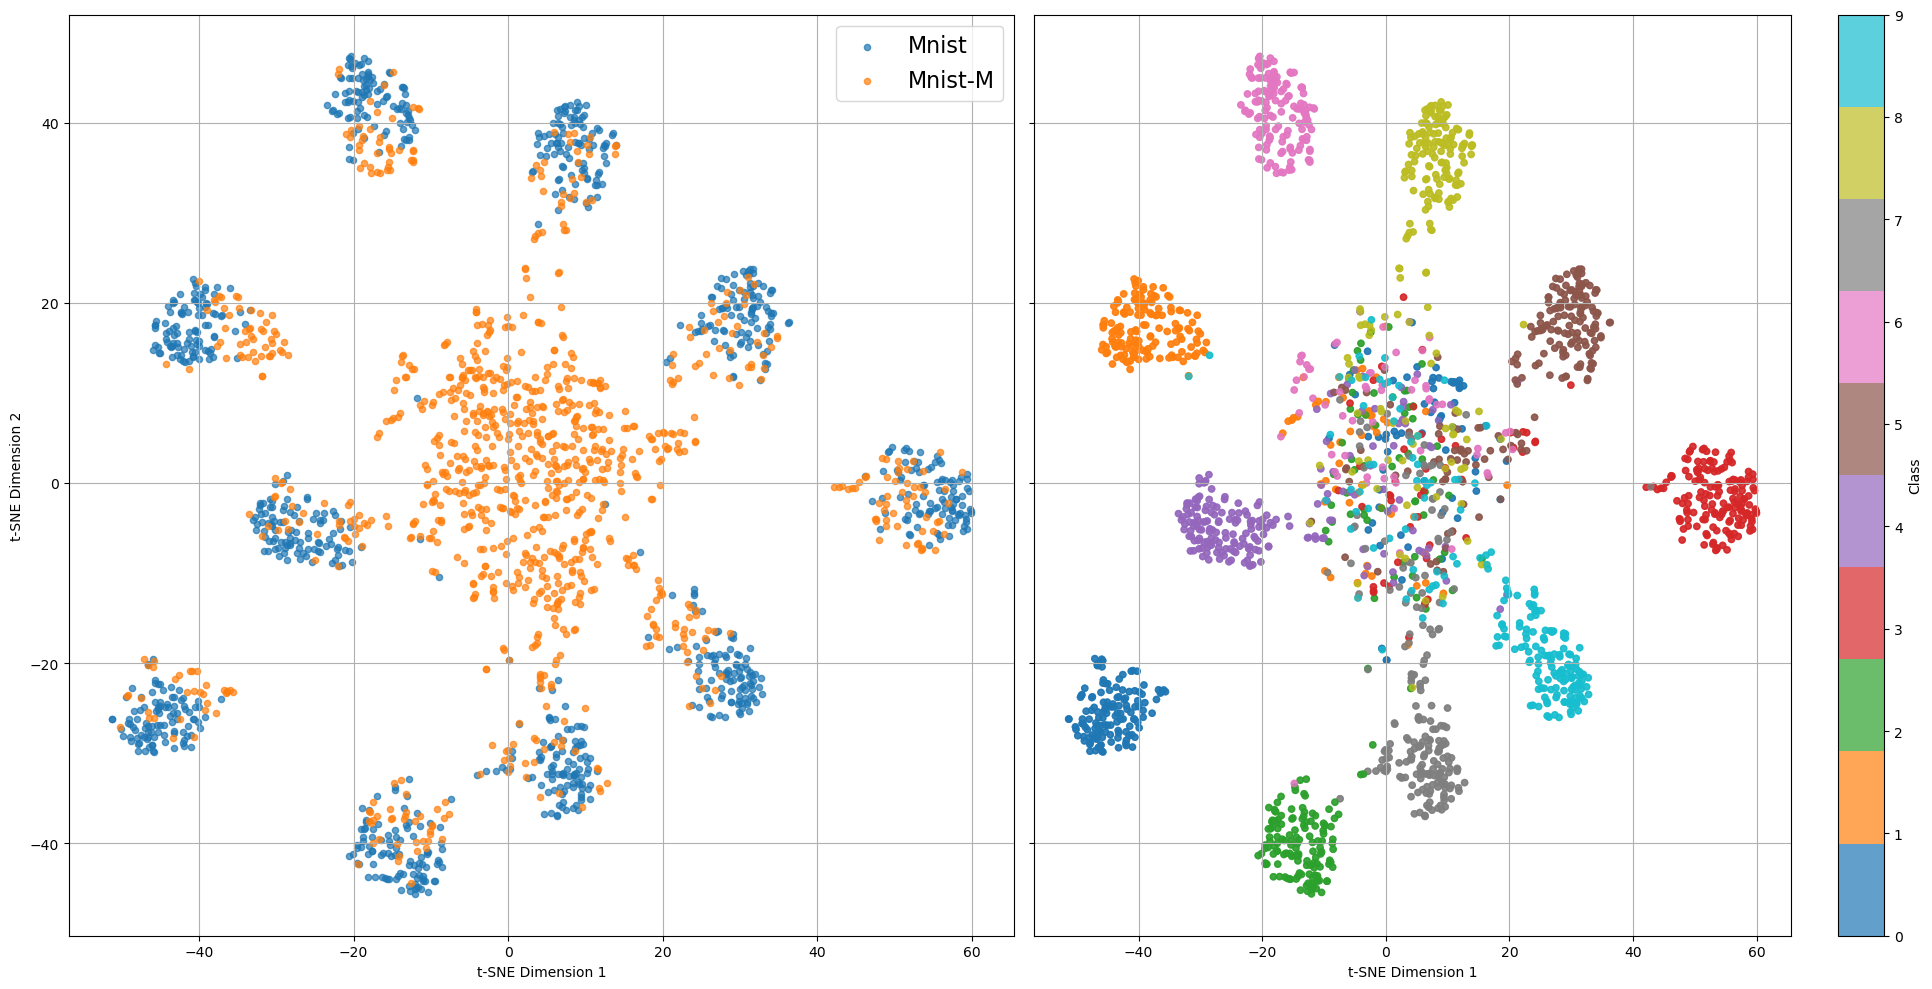

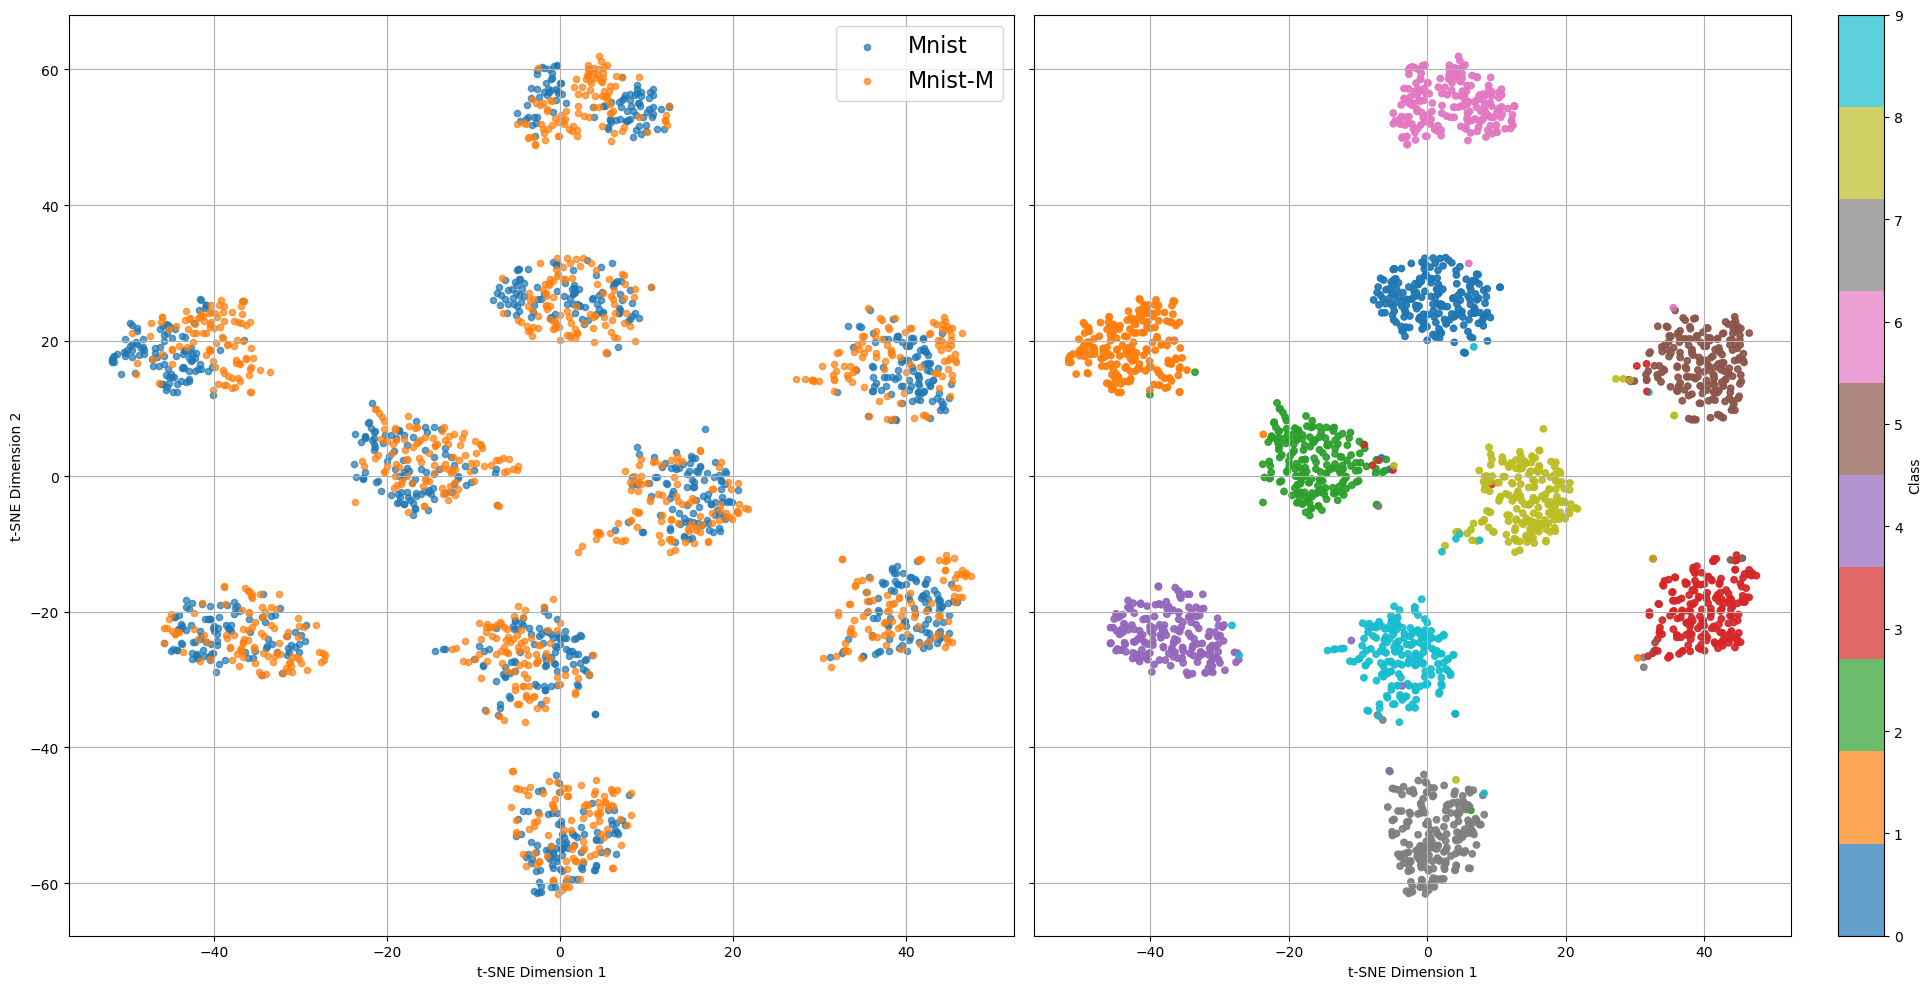

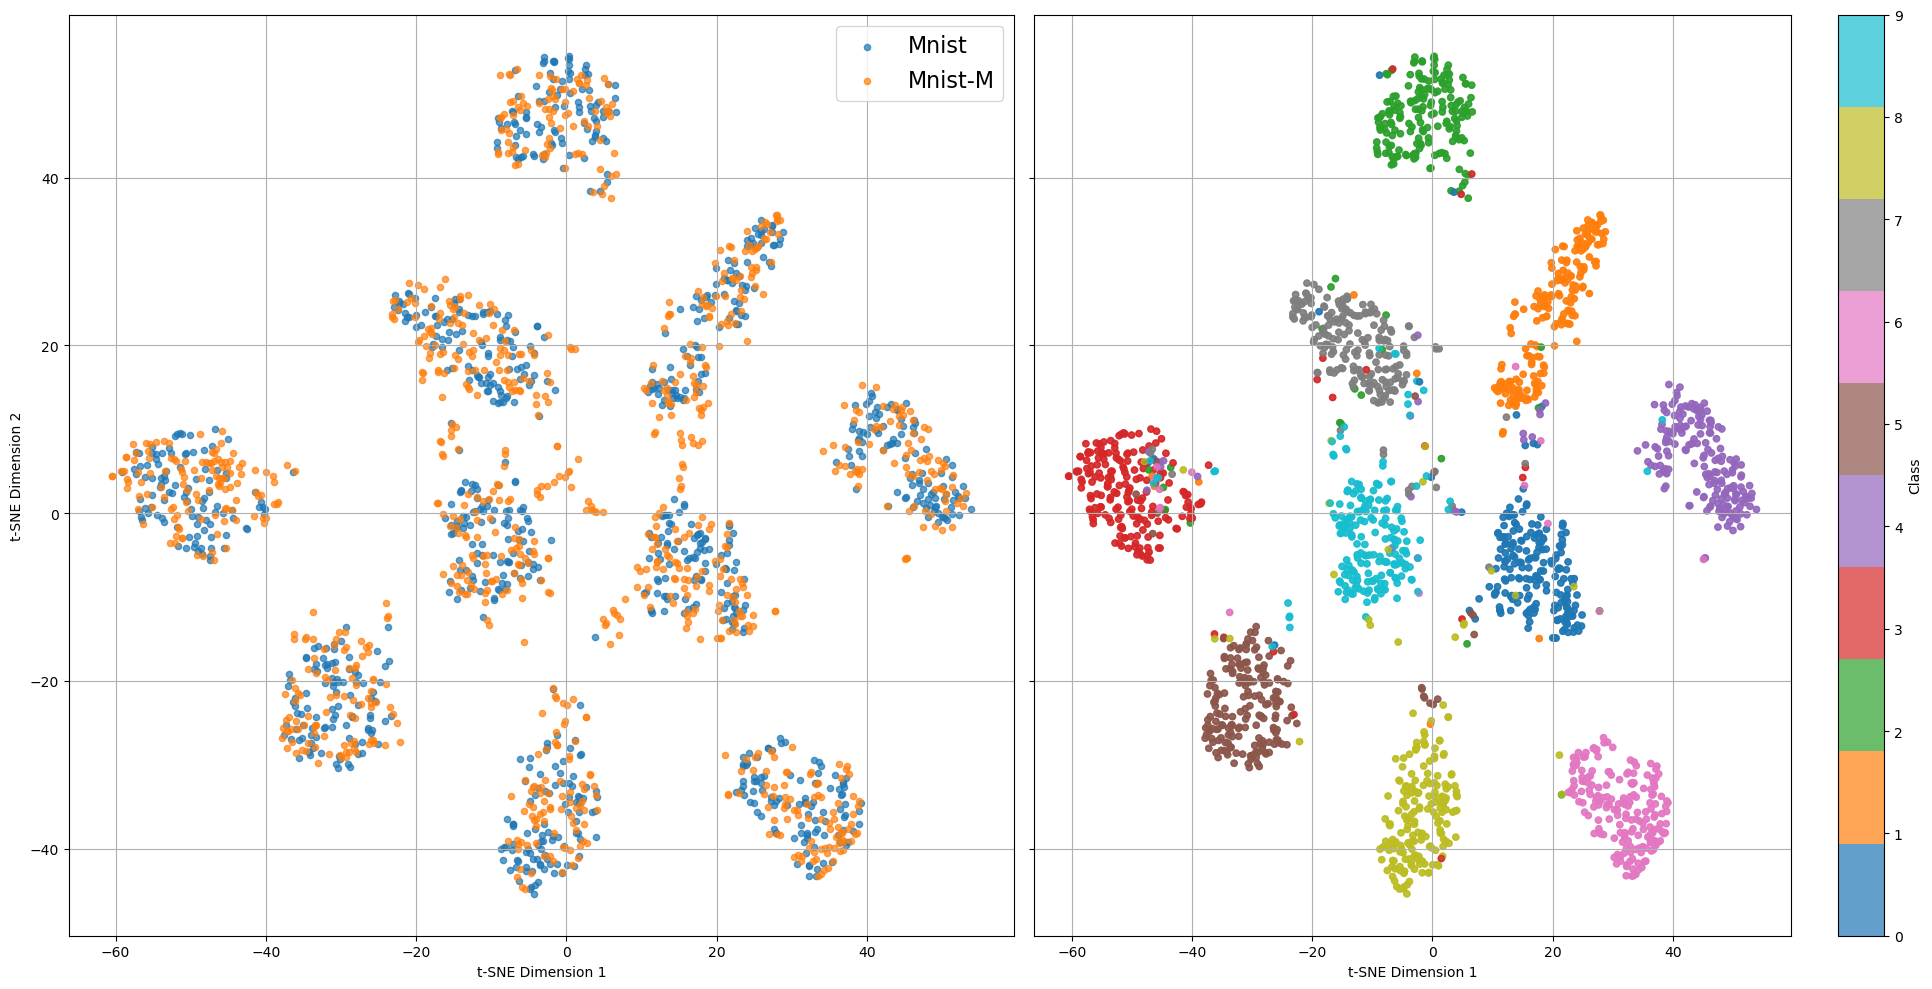

In [47]:
plot_tsnes(models=[dann_baseline_model, dann_baseline_ft_model, dann_model], models_name=["Baseline", "Baseline ft", "DANN"], test_data=test_data, samples_per_class=100, device=device)